# Black Scholes Barenblatt benchmark

This notebook is a simple positive control for the Deep BSDE implementation used in the dissertation.

The problem is regular and has a closed-form solution. The terminal target is fixed, so there is no moving boundary and no endogenous stopping rule. The purpose is only to check that the forward Deep BSDE code can learn a known two-dimensional value field.

The notebook contains four things:

1. the exact benchmark and simulation setup
2. the terminal mean-square Deep BSDE loss
3. a short training run with validation-based checkpoint selection
4. independent metrics and exact-versus-learned field plots


## 1 Setup

The benchmark uses T = 1, r = 0.05 and volatility = 0.2. Initial states are sampled uniformly from [0.5, 1.5] in each coordinate.

The exact field is

u(t, x1, x2) = 0.5 * exp((r + volatility^2) * (T - t)) * (x1^2 + x2^2).

The terminal payoff is 0.5 * (x1^2 + x2^2).

A value network learns the initial field over the whole starting region. A separate integrand network is used at each Euler time step. Exchange symmetry is imposed by construction.


In [1]:
from __future__ import annotations

import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import Tensor, nn
from IPython.display import display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

RESULTS_DIR = Path("black_scholes_barenblatt_benchmark_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Results directory:", RESULTS_DIR.resolve())


@dataclass(frozen=True)
class Config:
    terminal_time: float = 1.0
    rate: float = 0.05
    volatility: float = 0.2
    steps: int = 20
    width: int = 64

    iterations: int = 15_000
    batch_size: int = 1_024
    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    gradient_clip: float = 10.0

    validation_size: int = 8_192
    test_size: int = 20_000
    validation_every: int = 200
    display_every: int = 1_000
    grid_size: int = 61


CFG = Config()

with (RESULTS_DIR / "configuration.json").open("w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


Device: cuda
Results directory: /content/black_scholes_barenblatt_benchmark_results


## 2 Exact solution and neural model

The forward state follows multiplicative Brownian motion with no drift.

The value network receives two symmetric features: the mean of the coordinates and half of their absolute difference. The martingale integrand is exchange-equivariant: swapping x1 and x2 swaps the two learned integrand components.


In [2]:
def exact_value(t: float | Tensor, x: Tensor) -> Tensor:
    t_tensor = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    factor = torch.exp(
        (CFG.rate + CFG.volatility**2) * (CFG.terminal_time - t_tensor)
    )
    return 0.5 * factor * x.square().sum(dim=1, keepdim=True)


def exact_z(t: float, x: Tensor) -> Tensor:
    factor = CFG.volatility * math.exp(
        (CFG.rate + CFG.volatility**2) * (CFG.terminal_time - t)
    )
    return factor * x.square()


class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        width: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        self.register_buffer("center", torch.tensor(center, dtype=DTYPE))
        self.register_buffer("scale", torch.tensor(scale, dtype=DTYPE))
        self.net = nn.Sequential(
            nn.Linear(input_dim, width),
            nn.Softplus(),
            nn.Linear(width, width),
            nn.Softplus(),
            nn.Linear(width, output_dim),
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net((x - self.center) / self.scale)


class DeepBSDEModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.value_net = MLP(
            input_dim=2,
            output_dim=1,
            width=CFG.width,
            center=(1.0, 0.25),
            scale=(0.5, 0.25),
        )

        self.z_nets = nn.ModuleList(
            [
                MLP(
                    input_dim=2,
                    output_dim=1,
                    width=CFG.width,
                    center=(1.0, 1.0),
                    scale=(0.5, 0.5),
                )
                for _ in range(CFG.steps)
            ]
        )

    @staticmethod
    def symmetric_features(x: Tensor) -> Tensor:
        mean = 0.5 * (x[:, 0] + x[:, 1])
        half_difference = 0.5 * (x[:, 0] - x[:, 1]).abs()
        return torch.stack((mean, half_difference), dim=1)

    def initial_value(self, x: Tensor) -> Tensor:
        return self.value_net(self.symmetric_features(x))

    def z(self, step: int, x: Tensor) -> Tensor:
        component_net = self.z_nets[step]
        z1 = component_net(x)
        z2 = component_net(x[:, [1, 0]])
        return torch.cat((z1, z2), dim=1)


model = DeepBSDEModel().to(DEVICE)

print("Trainable parameters:", sum(p.numel() for p in model.parameters()))


Trainable parameters: 92757


## 3 Deep BSDE loss

For each batch, the code samples initial states and Brownian increments, propagates the forward state and the learned backward value through the Euler grid, and compares the final learned value with the fixed terminal payoff.

The training loss is the mean squared terminal error.

This is deliberately simple. There is no boundary loss, no stopping time and no analytical information used during training apart from the prescribed terminal payoff.


In [3]:
def make_generator(seed: int) -> torch.Generator:
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    return g


def sample_initial(batch_size: int, generator: torch.Generator) -> Tensor:
    x = 0.5 + torch.rand(batch_size, 2, generator=generator, dtype=DTYPE)
    return x.to(DEVICE)


def brownian_increments(
    batch_size: int,
    generator: torch.Generator,
    *,
    antithetic: bool,
) -> Tensor:
    dt = CFG.terminal_time / CFG.steps

    if antithetic:
        if batch_size % 2 != 0:
            raise ValueError("Antithetic batch size must be even.")
        half = batch_size // 2
        z = torch.randn(half, CFG.steps, 2, generator=generator, dtype=DTYPE)
        z = torch.cat((z, -z), dim=0)
    else:
        z = torch.randn(
            batch_size, CFG.steps, 2, generator=generator, dtype=DTYPE
        )

    return (math.sqrt(dt) * z).to(DEVICE)


def sample_batch(
    batch_size: int,
    generator: torch.Generator,
    *,
    antithetic: bool,
) -> tuple[Tensor, Tensor]:
    if antithetic:
        half = batch_size // 2
        x_half = sample_initial(half, generator)
        x0 = torch.cat((x_half, x_half.clone()), dim=0)
    else:
        x0 = sample_initial(batch_size, generator)

    d_w = brownian_increments(
        batch_size,
        generator,
        antithetic=antithetic,
    )
    return x0, d_w


def forward_deep_bsde(
    current_model: DeepBSDEModel,
    x0: Tensor,
    d_w: Tensor,
) -> tuple[Tensor, Tensor]:
    dt = CFG.terminal_time / CFG.steps

    x = x0
    y = current_model.initial_value(x0)

    for k in range(CFG.steps):
        z = current_model.z(k, x)

        # From the benchmark FBSDE:
        # dY = r * (Y - sum(Z)/volatility) dt + Z dW
        drift = CFG.rate * (
            y - z.sum(dim=1, keepdim=True) / CFG.volatility
        )

        y = y + drift * dt + (z * d_w[:, k]).sum(dim=1, keepdim=True)
        x = x + CFG.volatility * x * d_w[:, k]

    terminal_target = 0.5 * x.square().sum(dim=1, keepdim=True)
    return y, terminal_target


def deep_bsde_loss(
    current_model: DeepBSDEModel,
    x0: Tensor,
    d_w: Tensor,
) -> Tensor:
    y_terminal, target = forward_deep_bsde(current_model, x0, d_w)
    return (y_terminal - target).square().mean()


# A quick shape check before training.
check_generator = make_generator(SEED + 1)
check_x0, check_dw = sample_batch(8, check_generator, antithetic=True)
check_y, check_target = forward_deep_bsde(model, check_x0, check_dw)

print("Initial-state shape:", tuple(check_x0.shape))
print("Brownian-increment shape:", tuple(check_dw.shape))
print("Terminal prediction shape:", tuple(check_y.shape))
print("Terminal target shape:", tuple(check_target.shape))


Initial-state shape: (8, 2)
Brownian-increment shape: (8, 20, 2)
Terminal prediction shape: (8, 1)
Terminal target shape: (8, 1)


## 4 Training

Training uses seed 123, batches of 1024 and 15000 Adam iterations. A fixed independent validation set is evaluated every 200 iterations. The checkpoint with the smallest validation loss is retained.

Only a short progress line is printed every 1000 iterations so the final notebook remains readable.


In [4]:
train_generator = make_generator(SEED + 100)
validation_generator = make_generator(SEED + 200)
test_generator = make_generator(SEED + 300)

validation_batch = sample_batch(
    CFG.validation_size,
    validation_generator,
    antithetic=False,
)
test_batch = sample_batch(
    CFG.test_size,
    test_generator,
    antithetic=False,
)

optimizer = torch.optim.Adam(model.parameters(), lr=CFG.learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CFG.scheduler_step,
    gamma=CFG.scheduler_gamma,
)

history = []
best_validation_loss = math.inf
best_iteration = 0
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

start_time = time.perf_counter()

for iteration in range(1, CFG.iterations + 1):
    model.train()

    x0, d_w = sample_batch(
        CFG.batch_size,
        train_generator,
        antithetic=True,
    )

    optimizer.zero_grad(set_to_none=True)
    loss = deep_bsde_loss(model, x0, d_w)

    if not torch.isfinite(loss):
        raise FloatingPointError(f"Non-finite loss at iteration {iteration}")

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
    optimizer.step()
    scheduler.step()

    training_loss = float(loss.detach().cpu())
    validation_loss = math.nan

    if (
        iteration == 1
        or iteration % CFG.validation_every == 0
        or iteration == CFG.iterations
    ):
        model.eval()
        with torch.no_grad():
            validation_loss = float(
                deep_bsde_loss(
                    model,
                    validation_batch[0],
                    validation_batch[1],
                ).cpu()
            )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_iteration = iteration
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    history.append(
        {
            "iteration": iteration,
            "training_loss": training_loss,
            "validation_loss": validation_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )

    if (
        iteration == 1
        or iteration % CFG.display_every == 0
        or iteration == CFG.iterations
    ):
        val_text = (
            f" | validation {validation_loss:.4e}"
            if math.isfinite(validation_loss)
            else ""
        )
        print(
            f"iteration {iteration:5d} | "
            f"training {training_loss:.4e}{val_text}"
        )

runtime_seconds = time.perf_counter() - start_time

model.load_state_dict(best_state)
torch.save(best_state, RESULTS_DIR / "best_model.pt")

history = pd.DataFrame(history)
history.to_csv(RESULTS_DIR / "training_history.csv", index=False)

print()
print("Best validation iteration:", best_iteration)
print("Best validation loss:", f"{best_validation_loss:.6e}")
print("Training time in minutes:", f"{runtime_seconds / 60:.2f}")


iteration     1 | training 3.8341e+00 | validation 2.6880e+00
iteration  1000 | training 2.2660e-03 | validation 2.1819e-03
iteration  2000 | training 5.7774e-04 | validation 4.8643e-04
iteration  3000 | training 2.2234e-04 | validation 1.9024e-04
iteration  4000 | training 2.4249e-04 | validation 2.2979e-04
iteration  5000 | training 3.0383e-04 | validation 3.9218e-04
iteration  6000 | training 3.9371e-04 | validation 3.7851e-04
iteration  7000 | training 2.2809e-04 | validation 2.1411e-04
iteration  8000 | training 4.3377e-04 | validation 5.0569e-04
iteration  9000 | training 3.0653e-04 | validation 3.6972e-04
iteration 10000 | training 2.0817e-04 | validation 2.1913e-04
iteration 11000 | training 2.2138e-04 | validation 2.5141e-04
iteration 12000 | training 3.9967e-04 | validation 2.8384e-04
iteration 13000 | training 1.9569e-04 | validation 2.0688e-04
iteration 14000 | training 2.3229e-04 | validation 2.3094e-04
iteration 15000 | training 1.9652e-04 | validation 2.2084e-04

Best va

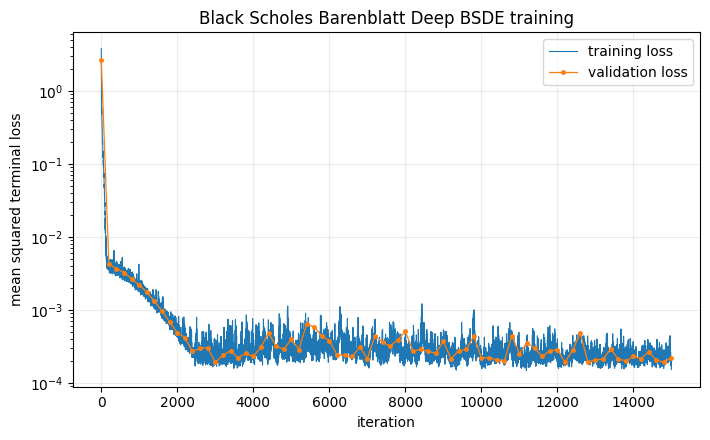

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))

train_rows = history[history["iteration"] > 0]
ax.semilogy(
    train_rows["iteration"],
    train_rows["training_loss"].clip(lower=1e-16),
    linewidth=0.8,
    label="training loss",
)

validation_rows = history.dropna(subset=["validation_loss"])
ax.semilogy(
    validation_rows["iteration"],
    validation_rows["validation_loss"].clip(lower=1e-16),
    marker="o",
    markersize=2.5,
    linewidth=0.9,
    label="validation loss",
)

ax.set_xlabel("iteration")
ax.set_ylabel("mean squared terminal loss")
ax.set_title("Black Scholes Barenblatt Deep BSDE training")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_loss.png", dpi=300, bbox_inches="tight")
plt.show()


## 5 Independent test metrics

The final checkpoint is evaluated on a separate test sample and on a regular spatial grid.

The main metrics are:

- terminal RMSE on independent simulated paths
- initial-field MAE, RMSE and maximum absolute error
- initial integrand RMSE at time zero
- the best validation loss and iteration

The field metrics compare the learned time-zero value directly with the closed-form solution.


In [6]:
@torch.no_grad()
def evaluate_model() -> tuple[pd.DataFrame, Tensor, Tensor, Tensor]:
    model.eval()

    # Independent terminal-path metric.
    y_terminal, target = forward_deep_bsde(
        model,
        test_batch[0],
        test_batch[1],
    )
    terminal_rmse = torch.sqrt(
        (y_terminal - target).square().mean()
    ).item()

    # Time-zero field and integrand metrics on a regular grid.
    grid = torch.linspace(0.5, 1.5, CFG.grid_size, device=DEVICE)
    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    learned_field = model.initial_value(points)[:, 0]
    exact_field = exact_value(0.0, points)[:, 0]

    learned_z0 = model.z(0, points)
    exact_z0 = exact_z(0.0, points)

    abs_error = (learned_field - exact_field).abs()

    metrics = {
        "terminal RMSE": terminal_rmse,
        "initial field MAE": abs_error.mean().item(),
        "initial field RMSE": torch.sqrt(
            (learned_field - exact_field).square().mean()
        ).item(),
        "initial field maximum error": abs_error.max().item(),
        "initial integrand RMSE": torch.sqrt(
            (learned_z0 - exact_z0).square().mean()
        ).item(),
        "best validation loss": best_validation_loss,
        "best validation iteration": best_iteration,
    }

    table = pd.DataFrame(
        {"metric": list(metrics.keys()), "value": list(metrics.values())}
    )

    return table, exact_field, learned_field, abs_error


metrics_table, exact_field, learned_field, absolute_error = evaluate_model()

metrics_table.to_csv(RESULTS_DIR / "metrics.csv", index=False)
display(metrics_table)


,metric,value
0,terminal RMSE,0.013850
1,initial field MAE,0.001379
2,initial field RMSE,0.002090
3,initial field maximum error,0.017733
4,initial integrand RMSE,0.010110
5,best validation loss,0.000190
6,best validation iteration,3000.000000


## 6 Exact and learned initial fields

The final figure compares the closed-form field with the learned Deep BSDE field at time zero. The third panel shows the absolute pointwise error.

A successful benchmark should produce two visually indistinguishable value surfaces and a small error panel.


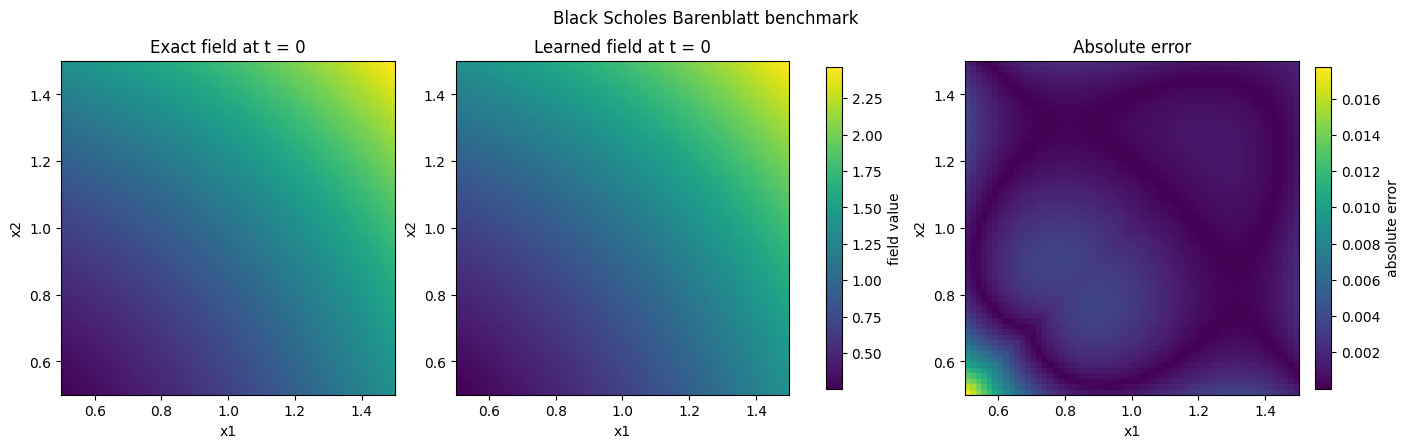

In [7]:
shape = (CFG.grid_size, CFG.grid_size)

exact_array = exact_field.reshape(shape).detach().cpu().numpy()
learned_array = learned_field.reshape(shape).detach().cpu().numpy()
error_array = absolute_error.reshape(shape).detach().cpu().numpy()

vmin = min(exact_array.min(), learned_array.min())
vmax = max(exact_array.max(), learned_array.max())

fig, axes = plt.subplots(
    1, 3,
    figsize=(14.0, 4.4),
    constrained_layout=True,
)

im0 = axes[0].imshow(
    exact_array.T,
    origin="lower",
    extent=[0.5, 1.5, 0.5, 1.5],
    aspect="equal",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Exact field at t = 0")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

im1 = axes[1].imshow(
    learned_array.T,
    origin="lower",
    extent=[0.5, 1.5, 0.5, 1.5],
    aspect="equal",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("Learned field at t = 0")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

im2 = axes[2].imshow(
    error_array.T,
    origin="lower",
    extent=[0.5, 1.5, 0.5, 1.5],
    aspect="equal",
)
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")

fig.colorbar(im1, ax=axes[:2], shrink=0.85, label="field value")
fig.colorbar(im2, ax=axes[2], shrink=0.85, label="absolute error")

fig.suptitle("Black Scholes Barenblatt benchmark")
fig.savefig(
    RESULTS_DIR / "field_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
